# Baseline Analysis and Robustness Checks

This notebook analyzes misinformation spread across Erdős-Rényi (ER), Watts-Strogatz (WS), and Barabási-Albert (BA) networks without intervention. It also:

- verifies the realized mean degree of each topology;
- reproduces the manuscript's baseline summaries and diagnostics;
- performs supplementary sensitivity sweeps over transmission probability and initial seed count;
- creates the consolidated manuscript and Supporting Online Material figures.


## Setup


In [1]:
from pathlib import Path
import json
import random

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import f_oneway, levene, kruskal, probplot
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.oneway import anova_oneway

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Figure directory:", FIGURE_DIR)

Project root: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research
Data directory: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\data
Figure directory: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\figures


In [2]:
result_candidates = [
    DATA_DIR / "baseline_results.csv",
    PROJECT_ROOT / "reproduced_baseline_results.csv",
    Path("/mnt/data/reproduced_baseline_results.csv"),
]
results_path = next((path for path in result_candidates if path.exists()), None)
if results_path is None:
    raise FileNotFoundError("Could not locate baseline_results.csv.")

curve_candidates = [
    DATA_DIR / "baseline_curves.json",
    PROJECT_ROOT / "baseline_curves.json",
]
curves_path = next((path for path in curve_candidates if path.exists()), None)

print("Results file:", results_path)
print("Curves file:", curves_path)
results = pd.read_csv(results_path)
results.head()

Results file: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\data\baseline_results.csv
Curves file: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\data\baseline_curves.json


,topology,trial,n,beta,gamma,t10,t50,peak_infected,auc,final_size,duration
0,ER,0,1000,0.15,0.05,6,10,706,19207.5,0.986,153
1,ER,1,1000,0.15,0.05,5,9,725,20140.5,0.987,167
2,ER,2,1000,0.15,0.05,5,9,746,20514.5,0.994,140
3,ER,3,1000,0.15,0.05,7,11,711,19102.5,0.991,136
4,ER,4,1000,0.15,0.05,6,10,720,19185.5,0.991,162


These checks confirm that each topology has the expected number of trials and that key metrics are available.


In [3]:
print("Rows:", len(results))
print("Columns:", list(results.columns))

results.groupby("topology").size()

Rows: 300
Columns: ['topology', 'trial', 'n', 'beta', 'gamma', 't10', 't50', 'peak_infected', 'auc', 'final_size', 'duration']


topology
BA    100
ER    100
WS    100
dtype: int64

In [4]:
# Missing-value check
results.isna().sum()

topology         0
trial            0
n                0
beta             0
gamma            0
t10              0
t50              0
peak_infected    0
auc              0
final_size       0
duration         0
dtype: int64

In [5]:
# Check whether any trials did not reach 10% or 50% infection.
reached_table = results.assign(
    reached_10=results["t10"].notna(),
    reached_50=results["t50"].notna()
).groupby("topology")[["reached_10", "reached_50"]].mean()

reached_table

,reached_10,reached_50
topology,,
BA,1.0,1.0
ER,1.0,1.0
WS,1.0,1.0


Lower `t10` and `t50` mean faster spread. Higher `peak_infected`, `final_size`, and `auc` indicate larger or more intense outbreaks.


In [6]:
summary = results.groupby("topology")[[
    "t10",
    "t50",
    "peak_infected",
    "final_size",
    "auc"
]].agg(["mean", "std", "median"])

summary

t10                     t50                  peak_infected  \
          mean       std median   mean       std median          mean   
topology                                                                
BA        4.76  0.975663    5.0   7.90  1.000000    8.0        738.21   
ER        6.14  0.778758    6.0  10.41  0.888706   10.0        728.26   
WS        8.73  1.153431    9.0  17.76  1.511705   18.0        639.02   

                           final_size                        auc              \
                std median       mean       std median      mean         std   
topology                                                                       
BA        15.577305  739.0    0.99501  0.002699  0.995  19825.07  676.544970   
ER        15.224661  728.5    0.99041  0.003397  0.991  19844.99  530.899665   
WS        21.357931  638.0    0.99961  0.000650  1.000  19906.70  634.582086   

                   
           median  
topology           
BA        19834.0  
ER        19852.5  
WS        19875.5

In [7]:
# Cleaner table of means only for quick interpretation.
mean_summary = results.groupby("topology")[[
    "t10",
    "t50",
    "peak_infected",
    "final_size",
    "auc"
]].mean().sort_values("t50")

mean_summary

,t10,t50,peak_infected,final_size,auc
topology,,,,,
BA,4.76,7.90,738.21,0.99501,19825.07
ER,6.14,10.41,728.26,0.99041,19844.99
WS,8.73,17.76,639.02,0.99961,19906.70


## Figure 1 — Time to 10% infection

This measures early spread speed.


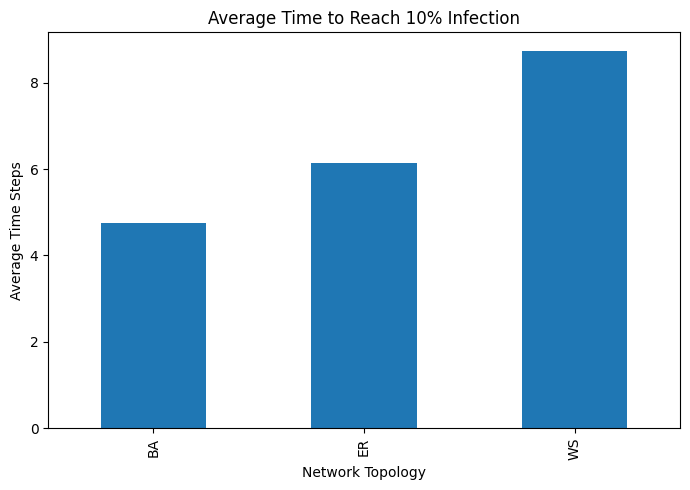

topology
BA    4.76
ER    6.14
WS    8.73
Name: t10, dtype: float64

In [8]:
plot_data = results.groupby("topology")["t10"].mean().sort_values()

ax = plot_data.plot(kind="bar", figsize=(7, 5))
ax.set_ylabel("Average Time Steps")
ax.set_xlabel("Network Topology")
ax.set_title("Average Time to Reach 10% Infection")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_t10_bar.png", dpi=300)
plt.show()
plt.close('all')

plot_data

## Figure 2 — Time to 50% infection

This is the primary baseline spread speed metric.


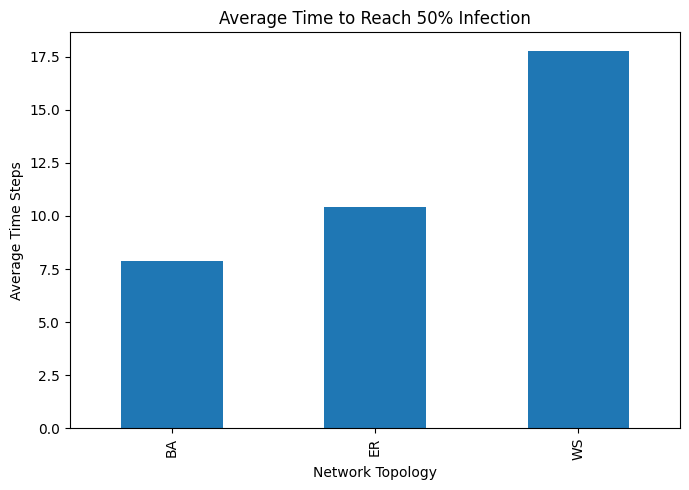

topology
BA     7.90
ER    10.41
WS    17.76
Name: t50, dtype: float64

In [9]:
plot_data = results.groupby("topology")["t50"].mean().sort_values()

ax = plot_data.plot(kind="bar", figsize=(7, 5))
ax.set_ylabel("Average Time Steps")
ax.set_xlabel("Network Topology")
ax.set_title("Average Time to Reach 50% Infection")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_t50_bar.png", dpi=300)
plt.show()
plt.close('all')

plot_data

## Figure 3 — Peak active spreaders

This measures the maximum number of nodes actively spreading misinformation at the same time.


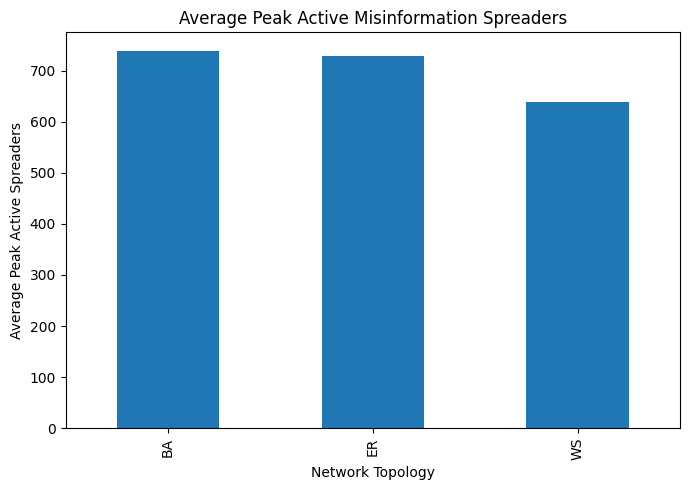

topology
BA    738.21
ER    728.26
WS    639.02
Name: peak_infected, dtype: float64

In [10]:
plot_data = results.groupby("topology")["peak_infected"].mean().sort_values(ascending=False)

ax = plot_data.plot(kind="bar", figsize=(7, 5))
ax.set_ylabel("Average Peak Active Spreaders")
ax.set_xlabel("Network Topology")
ax.set_title("Average Peak Active Misinformation Spreaders")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_peak_bar.png", dpi=300)
plt.show()
plt.close('all')

plot_data

## Figure 4 — Final outbreak size

This measures the fraction of nodes that were ever infected during the simulation.


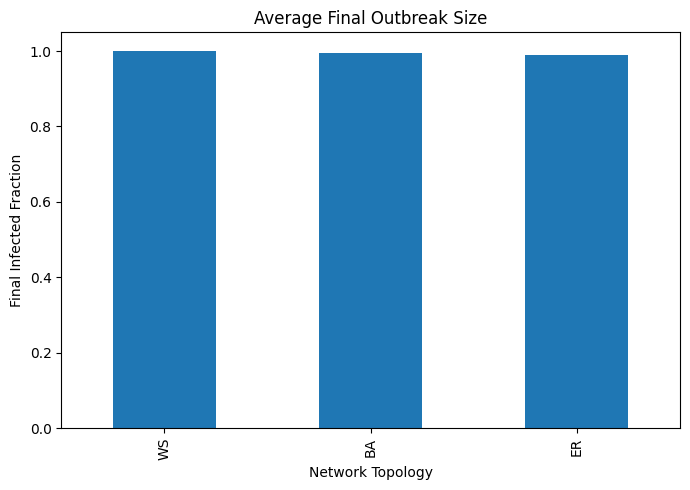

topology
WS    0.99961
BA    0.99501
ER    0.99041
Name: final_size, dtype: float64

In [11]:
plot_data = results.groupby("topology")["final_size"].mean().sort_values(ascending=False)

ax = plot_data.plot(kind="bar", figsize=(7, 5))
ax.set_ylabel("Final Infected Fraction")
ax.set_xlabel("Network Topology")
ax.set_title("Average Final Outbreak Size")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_final_size_bar.png", dpi=300)
plt.show()
plt.close('all')

plot_data

## Figure 5 — Area under infection curve

AUC approximates total misinformation burden over time. Higher AUC means more active spreaders over the full outbreak.


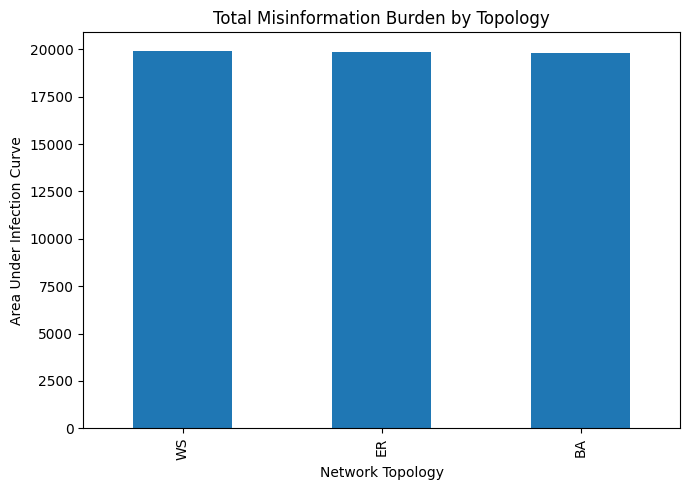

topology
WS    19906.70
ER    19844.99
BA    19825.07
Name: auc, dtype: float64

In [12]:
plot_data = results.groupby("topology")["auc"].mean().sort_values(ascending=False)

ax = plot_data.plot(kind="bar", figsize=(7, 5))
ax.set_ylabel("Area Under Infection Curve")
ax.set_xlabel("Network Topology")
ax.set_title("Total Misinformation Burden by Topology")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_auc_bar.png", dpi=300)
plt.show()
plt.close('all')

plot_data

Load and reshape infection curves


In [13]:
curve_df = None
if curves_path is not None:
    with open(curves_path, "r") as f:
        curves = json.load(f)

    max_length = max(len(item["infected_counts"]) for item in curves)
    curve_rows = []
    for item in curves:
        curve = item["infected_counts"]
        padded = curve + [0] * (max_length - len(curve))
        for time, infected in enumerate(padded):
            curve_rows.append({
                "topology": item["topology"],
                "trial": item["trial"],
                "time": time,
                "infected": infected,
            })
    curve_df = pd.DataFrame(curve_rows)
else:
    print("baseline_curves.json was not found; curve figures are skipped.")

## Figure 6 — Average misinformation spread curves

Shows the full time course rather than only summary metrics.


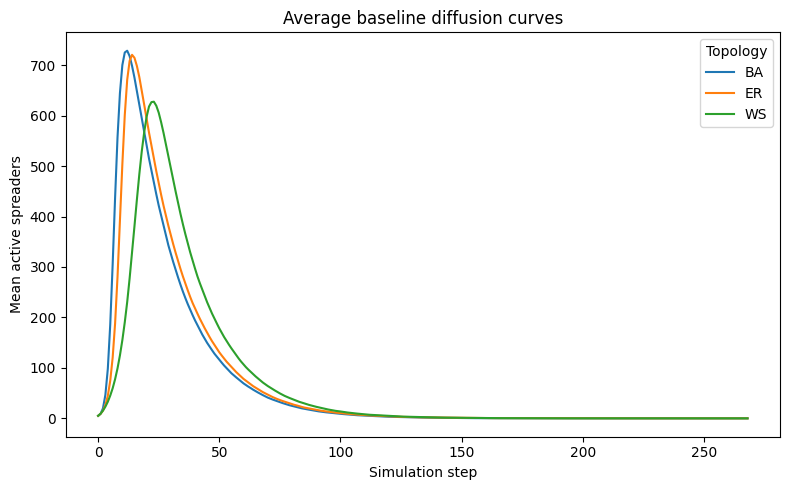

Saved: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\figures\figure2_baseline_curves.png


In [14]:
if curve_df is not None:
    avg_curve = curve_df.groupby(["topology", "time"])["infected"].mean().reset_index()
    plt.figure(figsize=(8, 5))
    for topology in ["BA", "ER", "WS"]:
        subset = avg_curve[avg_curve["topology"] == topology]
        plt.plot(subset["time"], subset["infected"], label=topology)
    plt.xlabel("Simulation step")
    plt.ylabel("Mean active spreaders")
    plt.title("Average baseline diffusion curves")
    plt.legend(title="Topology")
    plt.tight_layout()
    curve_figure_path = FIGURE_DIR / "figure2_baseline_curves.png"
    plt.savefig(curve_figure_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close('all')
    print("Saved:", curve_figure_path)

These ANOVA tests t10, t50, peak_infected, final_size, and auc differ across the three topologies.


In [15]:
anova_results = []

metrics = ["t10", "t50", "peak_infected", "final_size", "auc"]

for metric in metrics:
    ba = results[results["topology"] == "BA"][metric].dropna()
    er = results[results["topology"] == "ER"][metric].dropna()
    ws = results[results["topology"] == "WS"][metric].dropna()

    f_stat, p_value = f_oneway(ba, er, ws)

    anova_results.append({
        "metric": metric,
        "F_statistic": f_stat,
        "p_value": p_value
    })

anova_table = pd.DataFrame(anova_results)

anova_table

,metric,F_statistic,p_value
0,t10,421.862058,1.633090e-87
1,t50,1933.009171,5.274685e-171
2,peak_infected,961.818204,1.788259e-130
3,final_size,329.901258,3.566316e-76
4,auc,0.475740,6.218979e-01


## Statistical diagnostics and sensitivity analyses

The baseline inferential analysis reports the classical one-way ANOVA together with effect size (\(\eta^2\)), Holm-adjusted \(p\)-values, median-centered Levene tests, Welch ANOVA, and Kruskal-Wallis sensitivity tests. Q-Q plots are saved as Supporting Online Material. These checks are useful because threshold times are discrete and final outbreak size is bounded.

,Outcome,F,Raw p,eta_squared,Levene p,Welch ANOVA p,Kruskal-Wallis p,Holm p
0,Time to 10% infection,421.8621,0.0000,0.7396,0.0011,0.0000,0.0000,0.0000
1,Time to 50% infection,1933.0092,0.0000,0.9287,0.0000,0.0000,0.0000,0.0000
2,Peak active spreaders,961.8182,0.0000,0.8663,0.0029,0.0000,0.0000,0.0000
3,Final outbreak size,329.9013,0.0000,0.6896,0.0000,0.0000,0.0000,0.0000
4,Cumulative exposure (AUC),0.4757,0.6219,0.0032,0.1304,0.6438,0.7412,0.6219


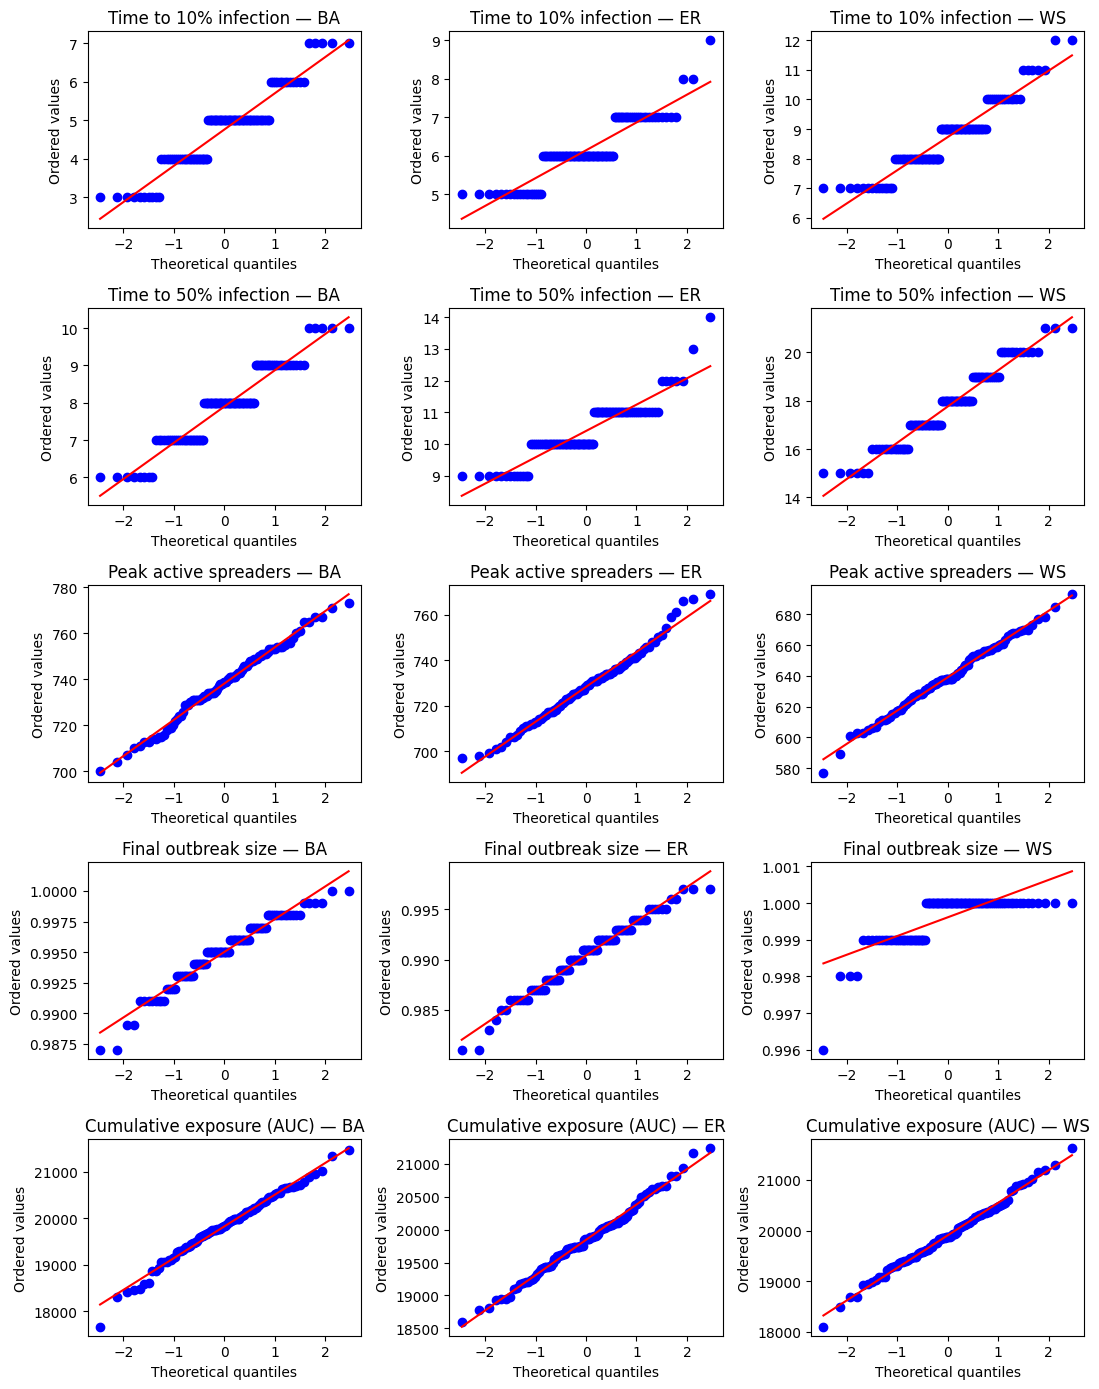

Saved: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\figures\baseline_qq_diagnostics.png


In [16]:
from scipy.stats import f_oneway, levene, kruskal, probplot
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.oneway import anova_oneway

metric_labels = {
    "t10": "Time to 10% infection",
    "t50": "Time to 50% infection",
    "peak_infected": "Peak active spreaders",
    "final_size": "Final outbreak size",
    "auc": "Cumulative exposure (AUC)",
}

diagnostic_rows = []
for metric in metric_labels:
    groups = [
        results.loc[results["topology"] == topology, metric].dropna()
        for topology in ["BA", "ER", "WS"]
    ]

    f_stat, p_value = f_oneway(*groups)
    df_between = len(groups) - 1
    df_within = sum(len(group) for group in groups) - len(groups)
    eta_squared = (
        (f_stat * df_between)
        / ((f_stat * df_between) + df_within)
    )

    diagnostic_rows.append({
        "Outcome": metric_labels[metric],
        "F": f_stat,
        "Raw p": p_value,
        "eta_squared": eta_squared,
        "Levene p": levene(*groups, center="median").pvalue,
        "Welch ANOVA p": anova_oneway(groups, use_var="unequal").pvalue,
        "Kruskal-Wallis p": kruskal(*groups).pvalue,
    })

baseline_diagnostics = pd.DataFrame(diagnostic_rows)
baseline_diagnostics["Holm p"] = multipletests(
    baseline_diagnostics["Raw p"],
    method="holm",
)[1]

display(baseline_diagnostics.round(4))

# Supporting Online Material: Q-Q plots for every outcome and topology.
fig, axes = plt.subplots(
    nrows=len(metric_labels),
    ncols=3,
    figsize=(11, 14),
)

for row, metric in enumerate(metric_labels):
    for col, topology in enumerate(["BA", "ER", "WS"]):
        ax = axes[row, col]
        values = results.loc[
            results["topology"] == topology,
            metric,
        ].dropna()

        probplot(values, dist="norm", plot=ax)
        ax.set_title(f"{metric_labels[metric]} — {topology}")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Ordered values")

fig.tight_layout()
qq_path = FIGURE_DIR / "baseline_qq_diagnostics.png"
fig.savefig(qq_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close('all')

baseline_diagnostics.to_csv(
    DATA_DIR / "baseline_statistical_diagnostics.csv",
    index=False,
)

print("Saved:", qq_path)

The median-centered Levene tests indicated unequal variances for time to 10% infection, time to 50% infection, peak active spreaders, and final outbreak size, but not for cumulative exposure. Welch ANOVA and Kruskal-Wallis tests reproduced the substantive conclusions of the classical ANOVAs: topology differences remained significant for the first four outcomes and remained non-significant for cumulative exposure.

## Consolidated baseline figure for the manuscript

This four-panel figure combines the baseline outcomes that were previously shown as separate bar charts. Error bars represent one standard deviation across 100 trials.

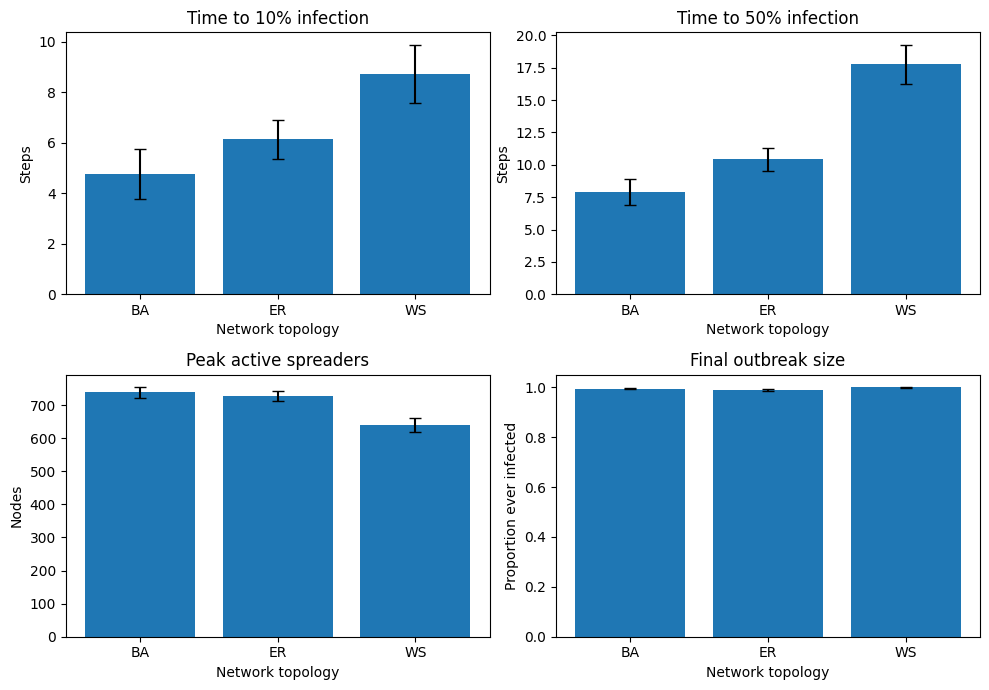

Saved: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\figures\figure1_baseline_outcomes.png


In [17]:
metric_specs = [
    ("t10", "Time to 10% infection", "Steps"),
    ("t50", "Time to 50% infection", "Steps"),
    ("peak_infected", "Peak active spreaders", "Nodes"),
    ("final_size", "Final outbreak size", "Proportion ever infected"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, (metric, title, ylabel) in zip(axes.flat, metric_specs):
    grouped = results.groupby("topology")[metric].agg(["mean", "std"]).reindex(["BA", "ER", "WS"])
    ax.bar(grouped.index, grouped["mean"], yerr=grouped["std"], capsize=4)
    ax.set_title(title)
    ax.set_xlabel("Network topology")
    ax.set_ylabel(ylabel)

fig.tight_layout()
consolidated_path = FIGURE_DIR / "figure1_baseline_outcomes.png"
fig.savefig(consolidated_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close('all')
print("Saved:", consolidated_path)

## Realized mean-degree comparability

The graph models were parameterized to have mean degree near 6. The table below verifies the realized mean degree across the 100 graph seeds used for each topology. BA has a slightly smaller finite-size mean degree because its average approaches \(2m\) asymptotically.

In [18]:
def build_graph(topology, n=1000, seed=0):
    if topology == "ER":
        return nx.erdos_renyi_graph(n, 6 / (n - 1), seed=seed)
    if topology == "WS":
        return nx.watts_strogatz_graph(n, 6, 0.10, seed=seed)
    if topology == "BA":
        return nx.barabasi_albert_graph(n, 3, seed=seed)
    raise ValueError(f"Unknown topology: {topology}")

mean_degree_rows = []
for topology in ["BA", "ER", "WS"]:
    for trial in range(100):
        graph = build_graph(topology, seed=trial)
        mean_degree_rows.append({
            "topology": topology,
            "trial": trial,
            "mean_degree": 2 * graph.number_of_edges() / graph.number_of_nodes(),
        })

mean_degree_trials = pd.DataFrame(mean_degree_rows)
mean_degree_summary = (
    mean_degree_trials.groupby("topology")["mean_degree"]
    .agg(["mean", "std", "min", "max"])
    .reindex(["BA", "ER", "WS"])
)
display(mean_degree_summary.round(3))
mean_degree_summary.to_csv(DATA_DIR / "realized_mean_degree_summary.csv")

,mean,std,min,max
topology,,,,
BA,5.982,0.000,5.982,5.982
ER,6.019,0.104,5.734,6.272
WS,6.000,0.000,6.000,6.000


## Supplementary sensitivity analysis

Two compact robustness checks were run with 50 matched graph realizations per topology:

1. transmission probability \(eta \in \{0.05, 0.15, 0.25\}\), with five initial spreaders;
2. initial spreaders \(\in \{1, 5, 10\}\), with \(eta=0.15\).

All other settings were unchanged: \(N=1000\), \(\gamma=0.05\), mean degree approximately 6, and a 500-step cap. The five-seed baseline corresponds to 0.5% of the network. The same graph realization and simulation random stream were reused across parameter values within each topology/trial block.

In [19]:
SUSCEPTIBLE, INFECTED, RECOVERED = 0, 1, 2

def run_sir_sensitivity(
    graph,
    beta=0.15,
    gamma=0.05,
    initial_infected_count=5,
    max_steps=500,
    random_seed=0,
):
    rng = random.Random(random_seed)
    nodes = list(graph.nodes())
    states = {node: SUSCEPTIBLE for node in nodes}
    initial = rng.sample(nodes, initial_infected_count)
    for node in initial:
        states[node] = INFECTED

    infected_counts = []
    total_ever_infected = set(initial)

    for _ in range(max_steps):
        infected_nodes = [node for node in nodes if states[node] == INFECTED]
        infected_counts.append(len(infected_nodes))
        if not infected_nodes:
            break

        new_infections = []
        new_recoveries = []
        for node in infected_nodes:
            for neighbor in graph.neighbors(node):
                if states[neighbor] == SUSCEPTIBLE and rng.random() < beta:
                    new_infections.append(neighbor)
            if rng.random() < gamma:
                new_recoveries.append(node)

        for node in new_infections:
            states[node] = INFECTED
            total_ever_infected.add(node)
        for node in new_recoveries:
            states[node] = RECOVERED

    counts = np.asarray(infected_counts, dtype=float)
    n = graph.number_of_nodes()

    def threshold_time(fraction):
        locations = np.flatnonzero(counts >= fraction * n)
        return float(locations[0]) if locations.size else np.nan

    return {
        "t10": threshold_time(0.10),
        "t50": threshold_time(0.50),
        "peak_infected": int(counts.max()) if counts.size else 0,
        "final_size": len(total_ever_infected) / n,
        "auc": float(np.trapezoid(counts)) if counts.size > 1 else 0.0,
        "reached_10": bool(np.any(counts >= 0.10 * n)),
        "reached_50": bool(np.any(counts >= 0.50 * n)),
        "duration": len(counts),
    }

SENSITIVITY_TRIALS = 50
beta_rows = []
seed_rows = []

for topology_index, topology in enumerate(["BA", "ER", "WS"]):
    for trial in range(SENSITIVITY_TRIALS):
        graph = build_graph(topology, seed=trial)

        for beta in [0.05, 0.15, 0.25]:
            metrics = run_sir_sensitivity(
                graph,
                beta=beta,
                gamma=0.05,
                initial_infected_count=5,
                random_seed=10_000_000 + topology_index * 100_000 + trial,
            )
            beta_rows.append({"topology": topology, "trial": trial, "beta": beta, **metrics})

        for initial_infected in [1, 5, 10]:
            metrics = run_sir_sensitivity(
                graph,
                beta=0.15,
                gamma=0.05,
                initial_infected_count=initial_infected,
                random_seed=20_000_000 + topology_index * 100_000 + trial,
            )
            seed_rows.append({
                "topology": topology,
                "trial": trial,
                "initial_infected": initial_infected,
                **metrics,
            })

beta_sensitivity = pd.DataFrame(beta_rows)
seed_sensitivity = pd.DataFrame(seed_rows)
beta_sensitivity.to_csv(DATA_DIR / "beta_sensitivity_results.csv", index=False)
seed_sensitivity.to_csv(DATA_DIR / "seed_count_sensitivity_results.csv", index=False)

beta_summary = beta_sensitivity.groupby(["beta", "topology"])[
    ["t10", "t50", "peak_infected", "final_size", "auc", "reached_50"]
].mean()
seed_summary = seed_sensitivity.groupby(["initial_infected", "topology"])[
    ["t10", "t50", "peak_infected", "final_size", "auc", "reached_50"]
].mean()

print("Transmission-probability sensitivity")
display(beta_summary.round(3))
print("Initial-seed sensitivity")
display(seed_summary.round(3))

Transmission-probability sensitivity


t10     t50  peak_infected  final_size       auc  reached_50
beta topology                                                                
0.05 BA        10.96  24.143         480.84       0.931  18782.58        0.28
     ER        16.44  34.000         459.84       0.947  18935.66        0.02
     WS        34.38     NaN         300.92       0.962  19252.46        0.00
0.15 BA         4.66   7.700         733.06       0.995  19887.74        1.00
     ER         5.98  10.260         726.96       0.990  19717.78        1.00
     WS         8.72  17.620         637.94       1.000  19998.76        1.00
0.25 BA         3.36   5.320         819.02       0.999  19962.12        1.00
     ER         4.16   6.800         810.60       0.995  19852.36        1.00
     WS         5.64  11.060         741.92       1.000  19979.78        1.00

Initial-seed sensitivity


t10     t50  peak_infected  final_size  \
initial_infected topology                                              
1                BA         7.408  10.571         721.38       0.974   
                 ER         9.792  13.875         701.00       0.951   
                 WS        16.531  25.878         621.98       0.980   
5                BA         4.540   7.580         738.44       0.995   
                 ER         5.940  10.220         731.20       0.991   
                 WS         8.480  17.340         643.98       1.000   
10               BA         3.700   6.860         739.10       0.995   
                 ER         4.620   8.780         726.14       0.990   
                 WS         6.060  14.600         647.92       1.000   

                                auc  reached_50  
initial_infected topology                        
1                BA        19473.54        0.98  
                 ER        19016.90        0.96  
                 WS        19552.64        0.98  
5                BA        19929.46        1.00  
                 ER        19831.18        1.00  
                 WS        20007.76        1.00  
10               BA        19848.80        1.00  
                 ER        19946.12        1.00  
                 WS        19895.48        1.00

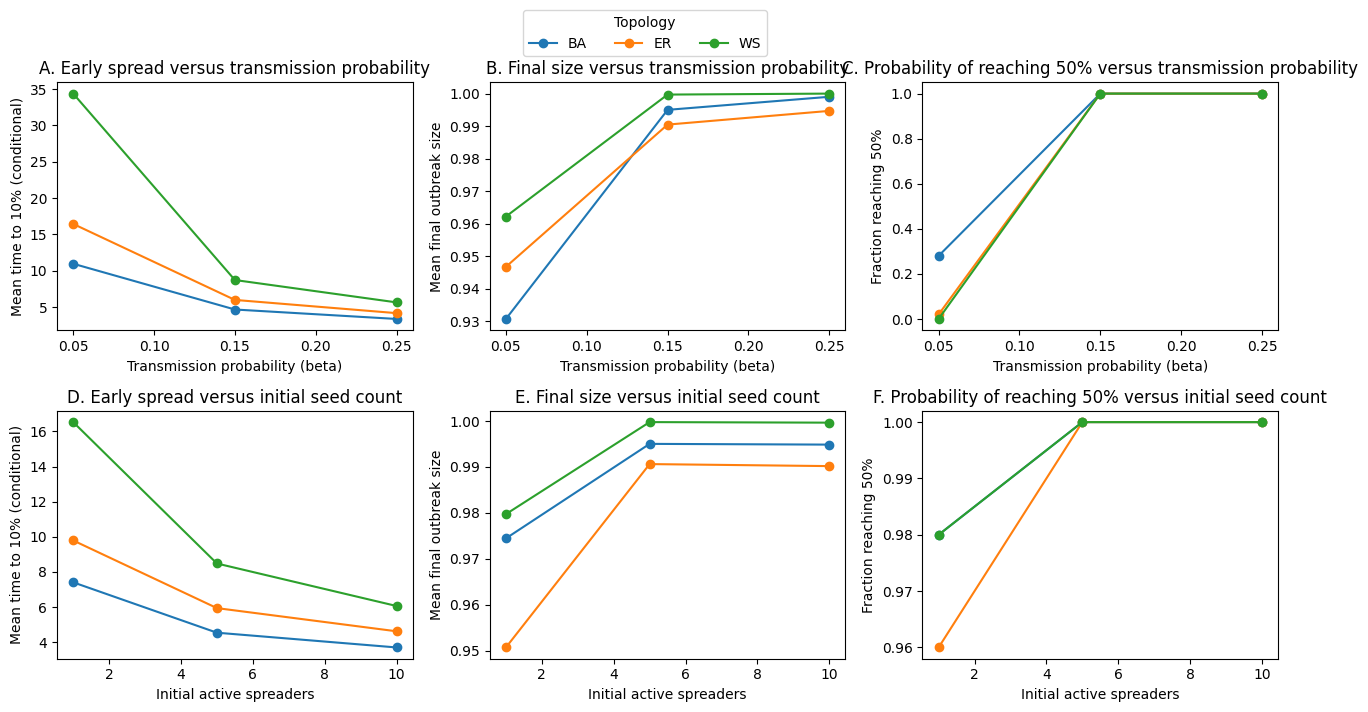

Saved: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\figures\supplementary_sensitivity_beta_seed.png


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
order = ["BA", "ER", "WS"]

for topology in order:
    beta_group = beta_summary.xs(topology, level="topology")
    axes[0, 0].plot(beta_group.index, beta_group["t10"], marker="o", label=topology)
    axes[0, 1].plot(beta_group.index, beta_group["final_size"], marker="o", label=topology)
    axes[0, 2].plot(beta_group.index, beta_group["reached_50"], marker="o", label=topology)

    seed_group = seed_summary.xs(topology, level="topology")
    axes[1, 0].plot(seed_group.index, seed_group["t10"], marker="o", label=topology)
    axes[1, 1].plot(seed_group.index, seed_group["final_size"], marker="o", label=topology)
    axes[1, 2].plot(seed_group.index, seed_group["reached_50"], marker="o", label=topology)

axes[0, 0].set_title("A. Early spread versus transmission probability")
axes[0, 1].set_title("B. Final size versus transmission probability")
axes[0, 2].set_title("C. Probability of reaching 50% versus transmission probability")
axes[1, 0].set_title("D. Early spread versus initial seed count")
axes[1, 1].set_title("E. Final size versus initial seed count")
axes[1, 2].set_title("F. Probability of reaching 50% versus initial seed count")

for ax in axes[0, :]:
    ax.set_xlabel("Transmission probability (beta)")
for ax in axes[1, :]:
    ax.set_xlabel("Initial active spreaders")
axes[0, 0].set_ylabel("Mean time to 10% (conditional)")
axes[1, 0].set_ylabel("Mean time to 10% (conditional)")
axes[0, 1].set_ylabel("Mean final outbreak size")
axes[1, 1].set_ylabel("Mean final outbreak size")
axes[0, 2].set_ylabel("Fraction reaching 50%")
axes[1, 2].set_ylabel("Fraction reaching 50%")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Topology", loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=(0, 0, 1, 0.96))
sensitivity_figure_path = FIGURE_DIR / "supplementary_sensitivity_beta_seed.png"
fig.savefig(sensitivity_figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close('all')
print("Saved:", sensitivity_figure_path)

**Supplementary Figure S1. Parameter sensitivity of baseline diffusion.** Panels A-C vary the per-edge transmission probability while holding five initial spreaders fixed. Panels D-F vary the initial spreader count while holding \(eta=0.15\). Points show means across 50 matched graph realizations per topology. Time to 10% infection is conditional on reaching that threshold; the threshold probabilities are shown separately. The BA-ER-WS ordering of early spread remained consistent across all tested values, while final-size differences were less stable when only one initial spreader was used.